In [29]:
# want to combine com and noncom cases into one workflow
# compare different values of a, define all lengths in terms of horizon radius
# will need to make two separate python scripts with the functions i will need to generate plots

In [30]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams["figure.dpi"] = 300
import shockFunc260331 as sf
import NCShockFunc260331 as nsf

In [31]:
num = 6000
sf.num = num
nsf.num = num

eps = 0.00001
sf.r0min = eps
sf.eps = eps
nsf.eps = eps

R = 1

In [32]:
r0grid = np.linspace(eps,R-eps,num)

calphagrid = sf.alpha(r0grid,R)
ncalphagrid = nsf.alpha(r0grid,R)

cmask = sf.k3(r0grid,R) > 0
ncmask = nsf.k3(r0grid,R) != 0

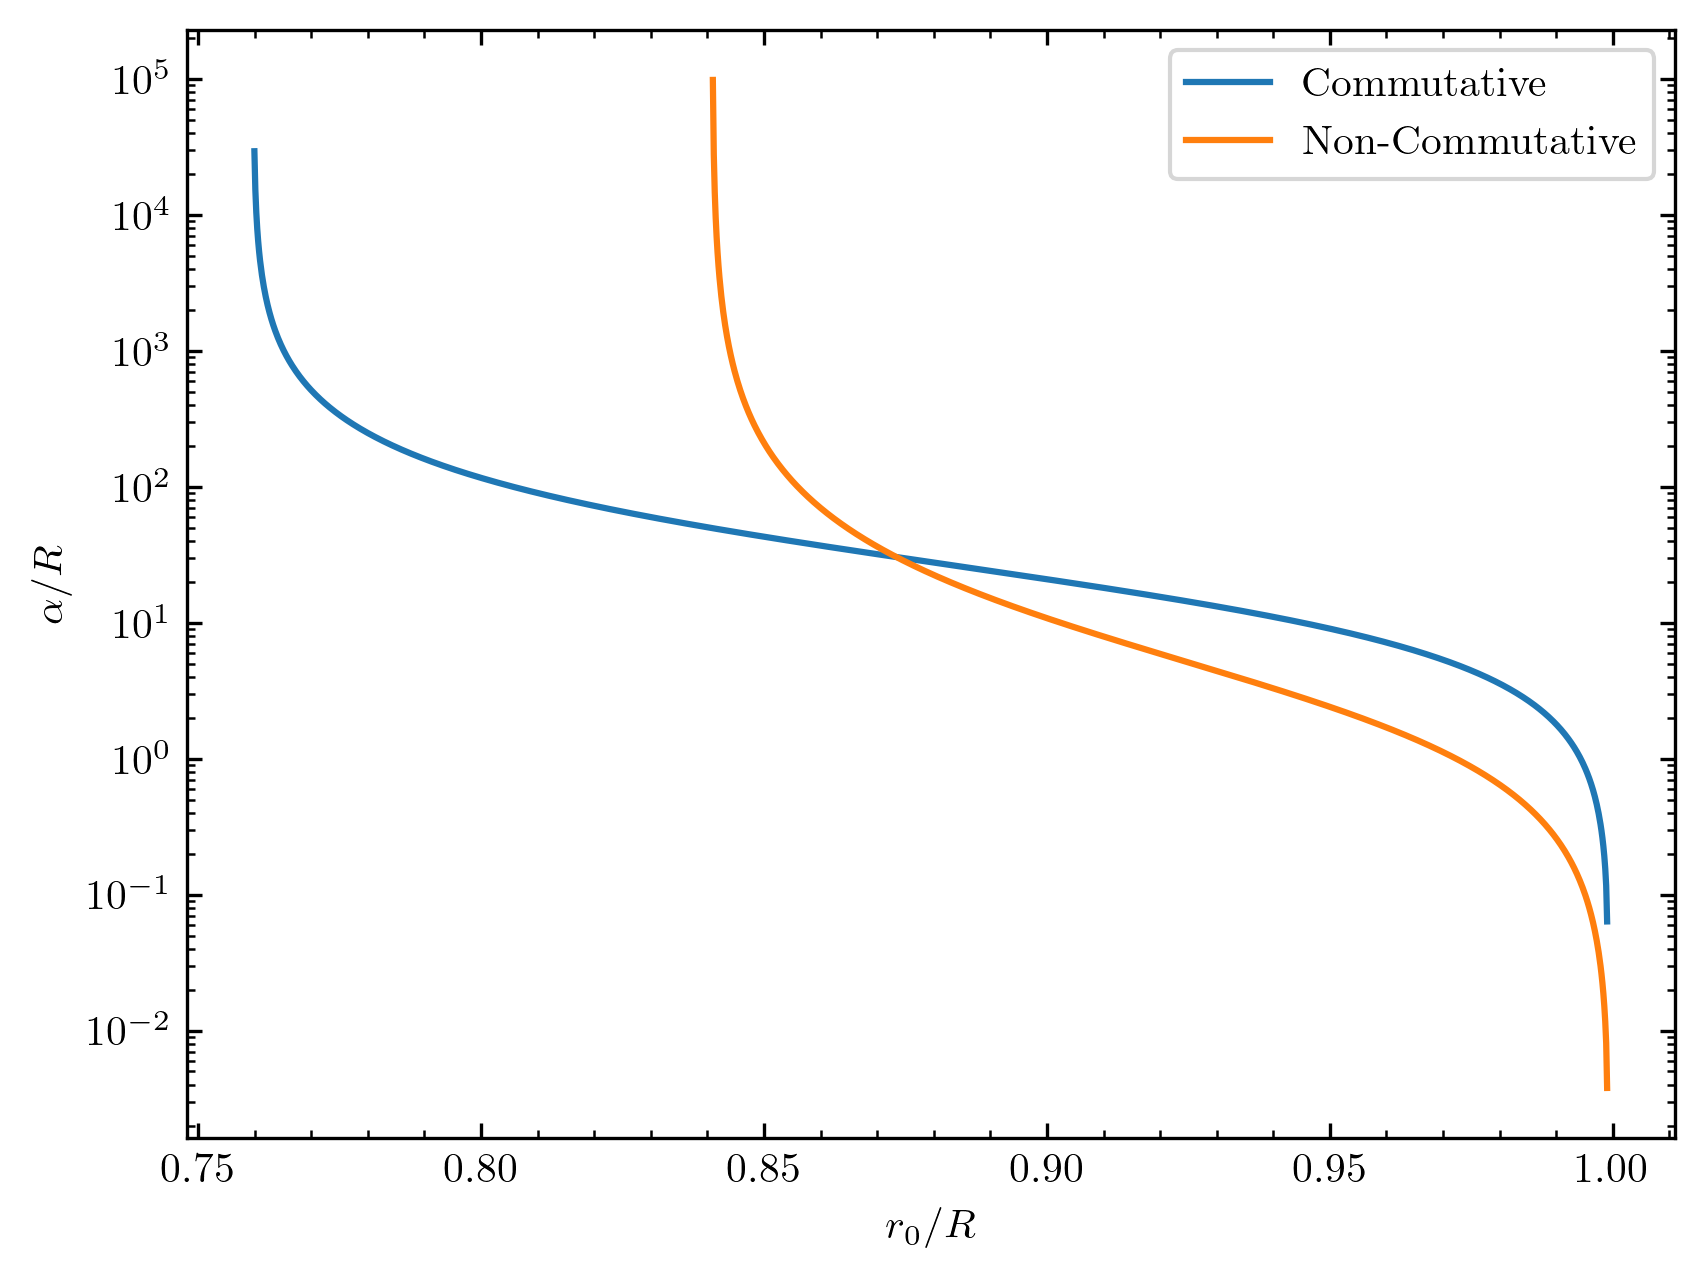

In [33]:
plt.plot(r0grid[cmask],calphagrid[cmask],label='Commutative')
plt.plot(r0grid[ncmask],ncalphagrid[ncmask],label='Non-Commutative')
plt.xlabel(r"$r_0 / R$")
plt.ylabel(r'$\alpha / R$')
plt.legend()
plt.semilogy()
# plt.show()
plt.savefig('combFigs/alphavsr0.pdf',format='pdf')

In [34]:
normcalphagrid = calphagrid[cmask]/calphagrid[cmask].max()
normncalphagrid = ncalphagrid[ncmask]/ncalphagrid[ncmask].max()

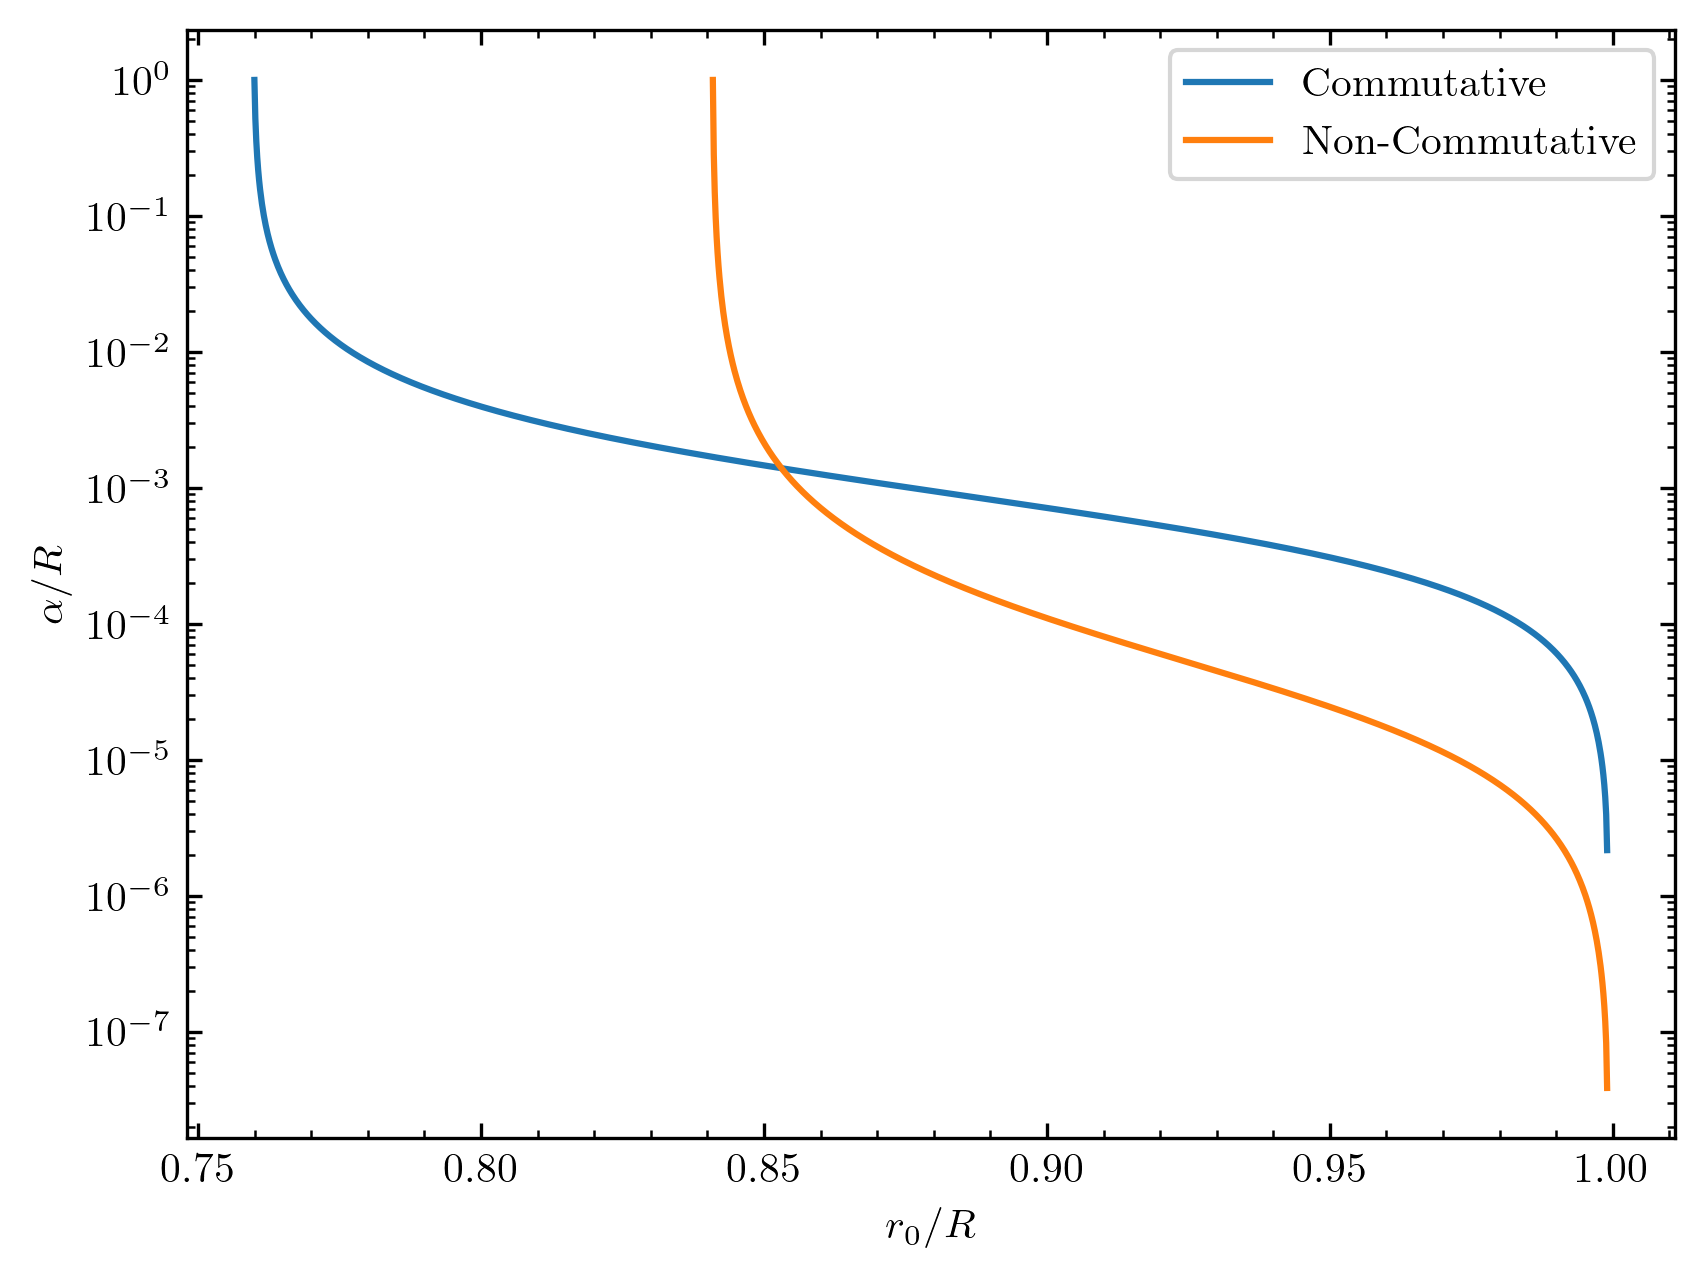

In [35]:
plt.plot(r0grid[cmask],normcalphagrid,label='Commutative')
plt.plot(r0grid[ncmask],normncalphagrid,label='Non-Commutative')
plt.xlabel(r"$r_0 / R$")
plt.ylabel(r'$\alpha / R$')
plt.legend()
plt.semilogy()
plt.savefig('combFigs/normalphavsr0.pdf',format='pdf')

In [36]:
careaInt = sf.shockArea(r0grid,R)
ncareaInt = nsf.shockArea(r0grid,R)

cmask = careaInt > 0
ncmask = ncareaInt > 0

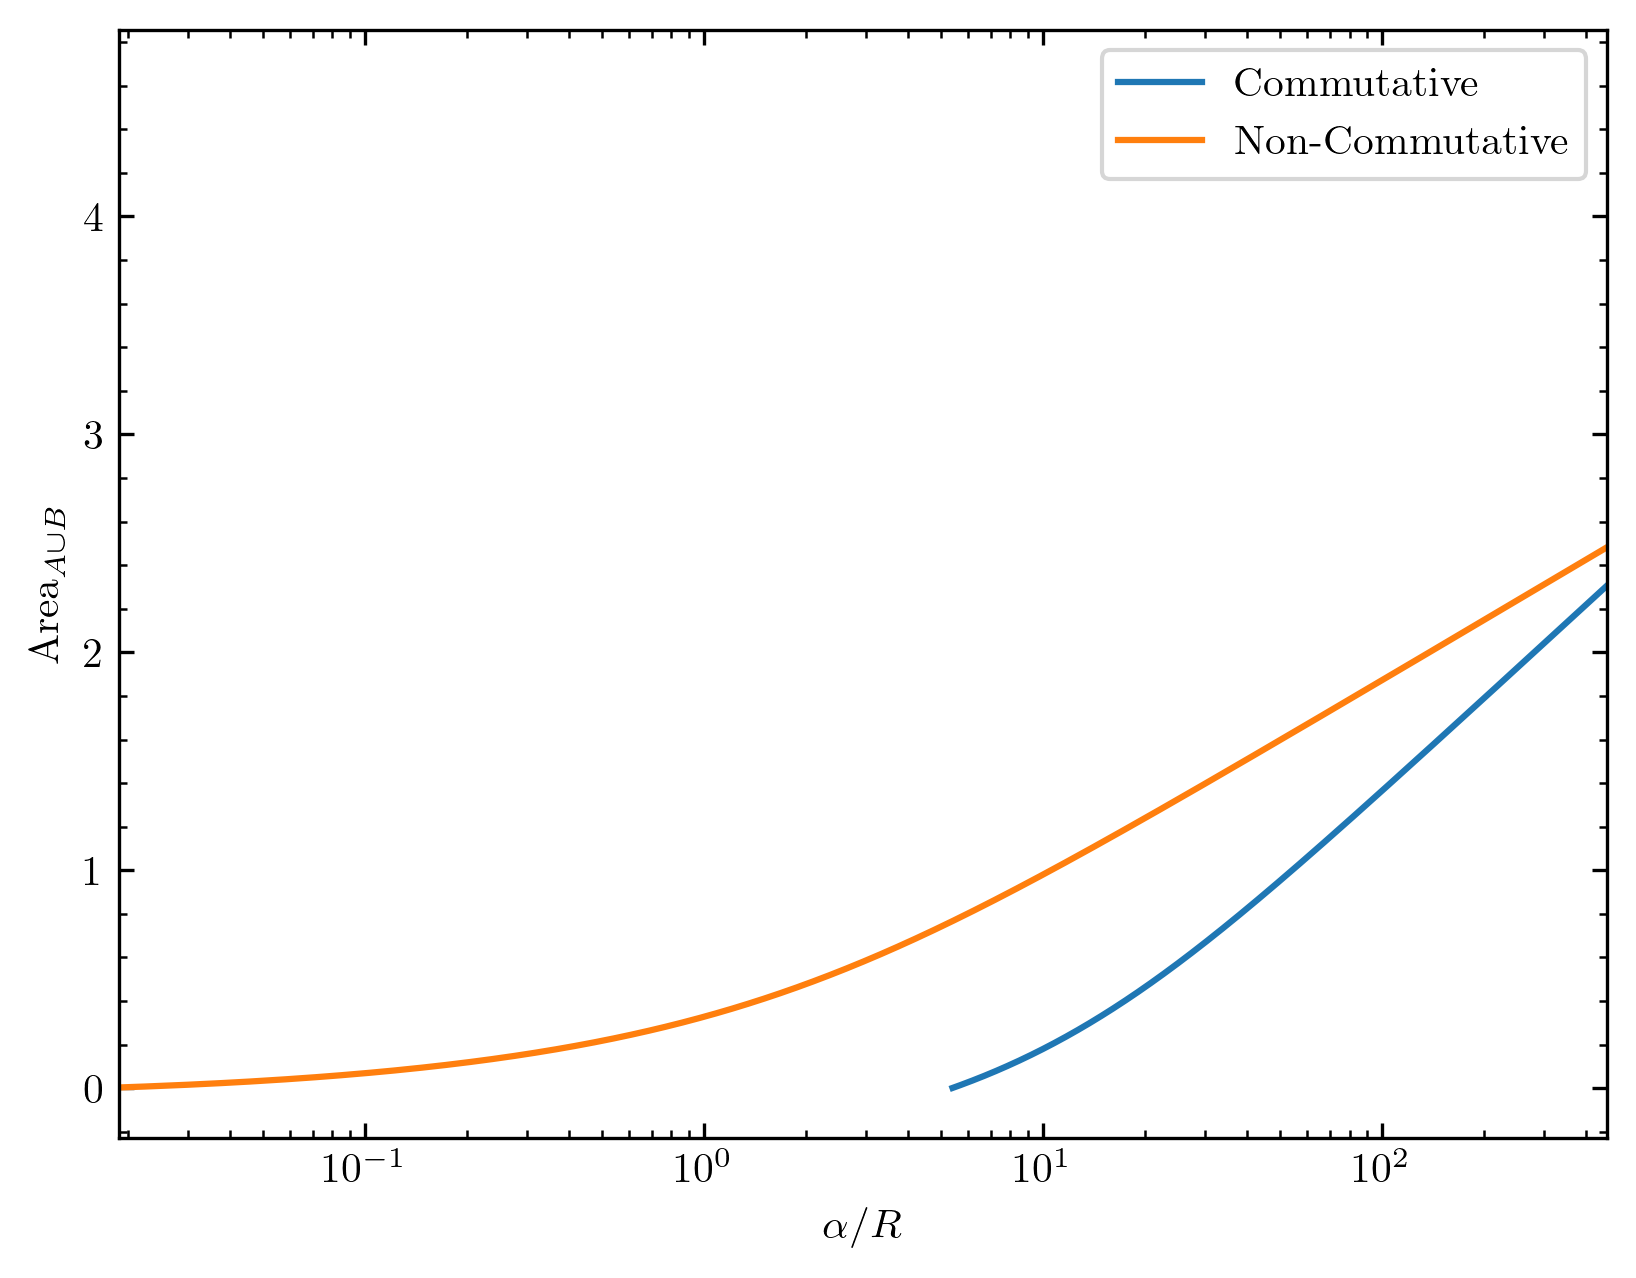

In [37]:
plt.plot(calphagrid[cmask],careaInt[cmask],label='Commutative')
plt.plot(ncalphagrid[ncmask],ncareaInt[ncmask],label='Non-Commutative')
plt.semilogx()
# plt.semilogy()
plt.legend()
plt.xlim((min(ncalphagrid[ncmask].min(),calphagrid[cmask].min()),min(ncalphagrid[ncmask].max(),calphagrid[cmask].max())))
plt.xlabel(r'$\alpha / R$')
plt.ylabel(r'Area$_{A \cup B}$')
# plt.show()
plt.savefig('combFigs/shockAvsalpha.pdf',format='pdf')

In [38]:
rminarr = np.logspace(np.log10(R+eps),np.log10(min([sf.rmax,nsf.rmax])),num)

cLvsrminarr = sf.Lvsrmin(rminarr,R)
ncLvsrminarr = nsf.Lvsrmin(rminarr,R,0.2)
ncLvsrminarr2 = nsf.Lvsrmin(rminarr,R,0.05)
ncLvsrminarr3 = nsf.Lvsrmin(rminarr,R,0.3)

/Users/bkorotko03/Desktop/Holography/HoloProj/NCShockFunc260331.py:133: RuntimeWarning: divide by zero encountered in divide
  integ = 2/np.sqrt((rarr**4) * f(rarr,R) * h(rarr,a) * b(rarr,rmin))


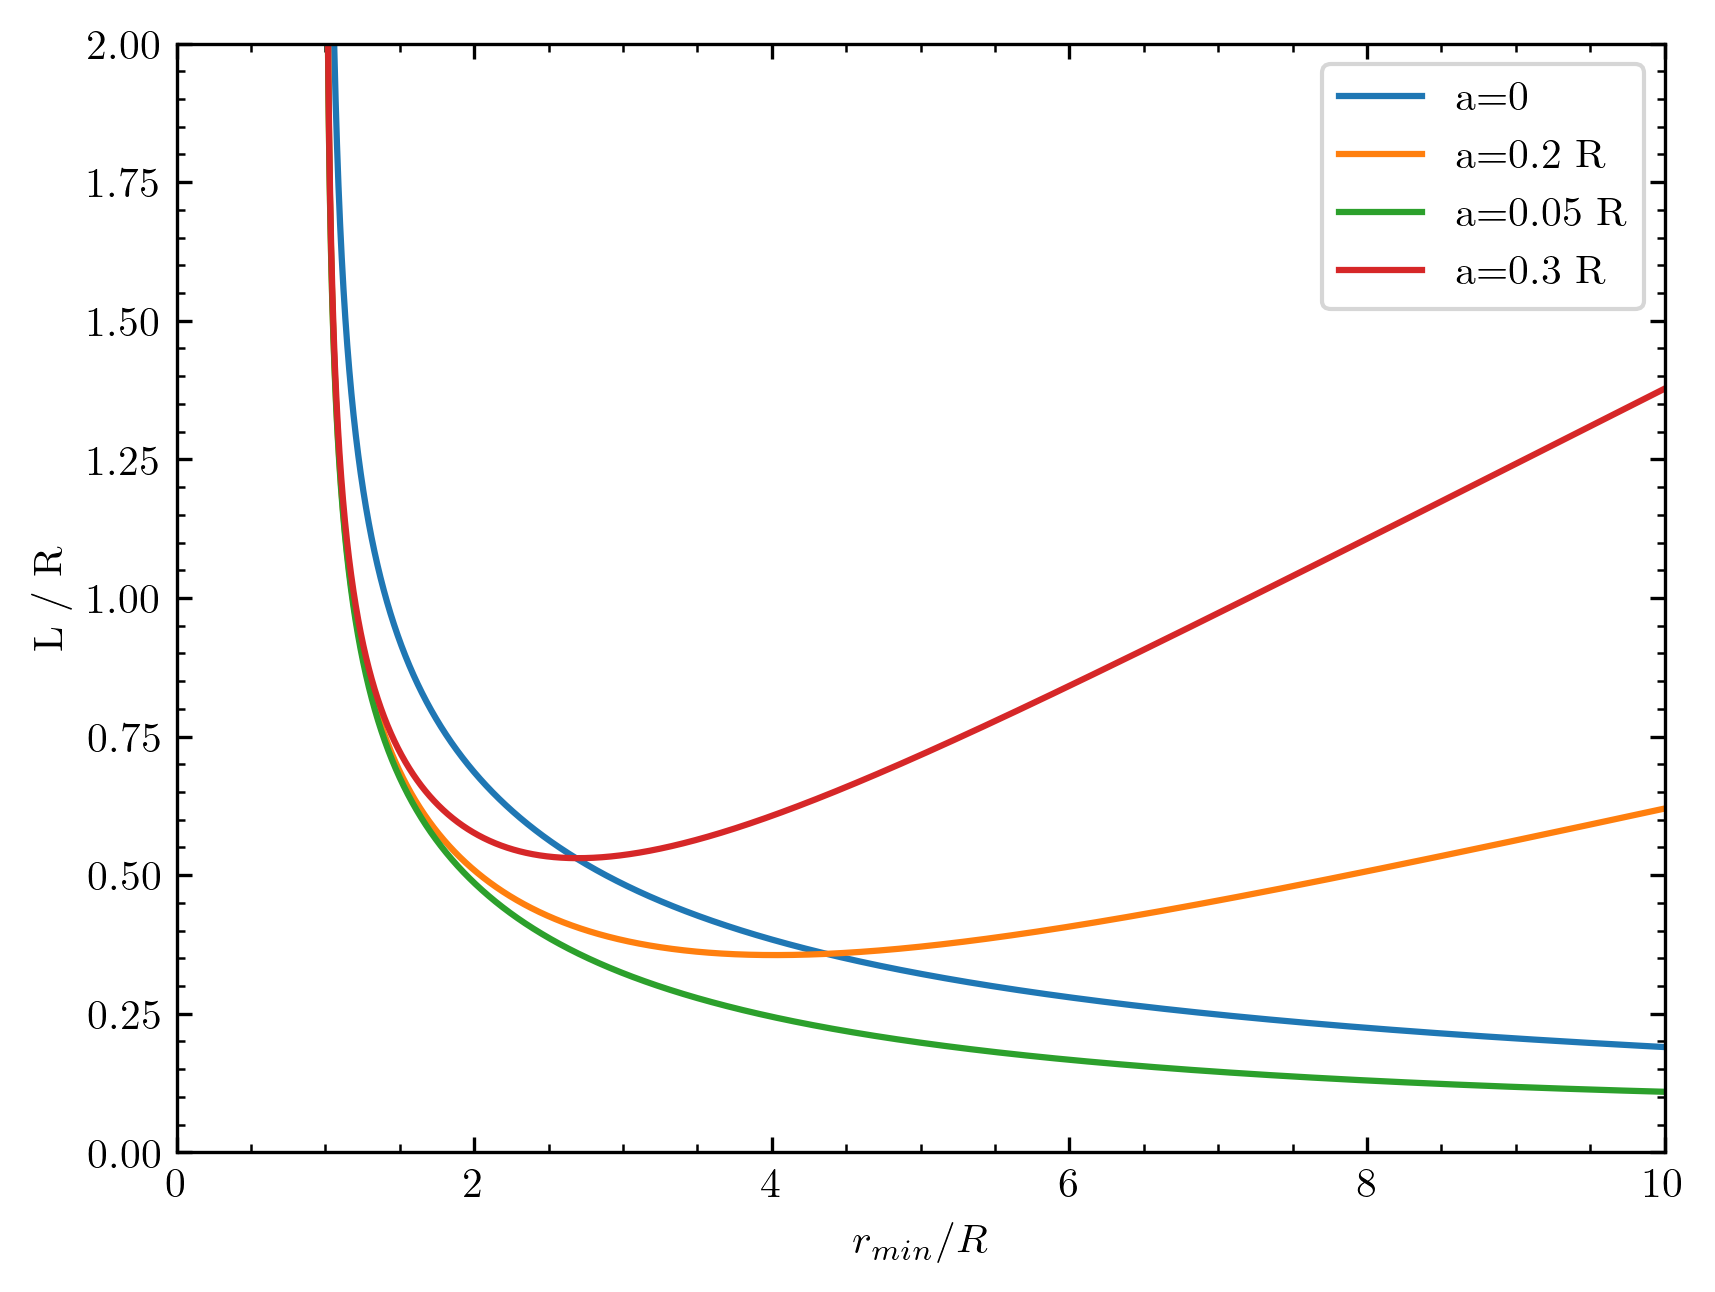

In [39]:
plt.plot(rminarr,cLvsrminarr,label='a=0')
plt.plot(rminarr,ncLvsrminarr,label='a=0.2 R')
plt.plot(rminarr,ncLvsrminarr2,label='a=0.05 R')
plt.plot(rminarr,ncLvsrminarr3,label='a=0.3 R')
plt.xlim((0,rminarr.max()/10))
plt.ylim((0,2))
plt.xlabel(r'$r_{min} / R$')
plt.ylabel(r'L / R')
# plt.semilogy()
plt.legend()
# plt.show()
plt.savefig('combFigs/Lvsrmin.pdf',format='pdf')

In [40]:
adjrminarr = nsf.rMinCutoff(rminarr,ncLvsrminarr)
adjrminarr2 = nsf.rMinCutoff(rminarr,ncLvsrminarr2)
adjrminarr3 = nsf.rMinCutoff(rminarr,ncLvsrminarr3)

In [41]:
adjncLvsrminarr = nsf.Lvsrmin(adjrminarr,R,0.2)
adjncLvsrminarr2 = nsf.Lvsrmin(adjrminarr2,R,0.05)
adjncLvsrminarr3 = nsf.Lvsrmin(adjrminarr3,R,0.3)

In [42]:
cunArea = sf.unAreaInt(rminarr,R)
ncunArea = nsf.unAreaInt(adjrminarr,R,0.2)
ncunArea2 = nsf.unAreaInt(adjrminarr2,R,0.05)
ncunArea3 = nsf.unAreaInt(adjrminarr3,R,0.3)

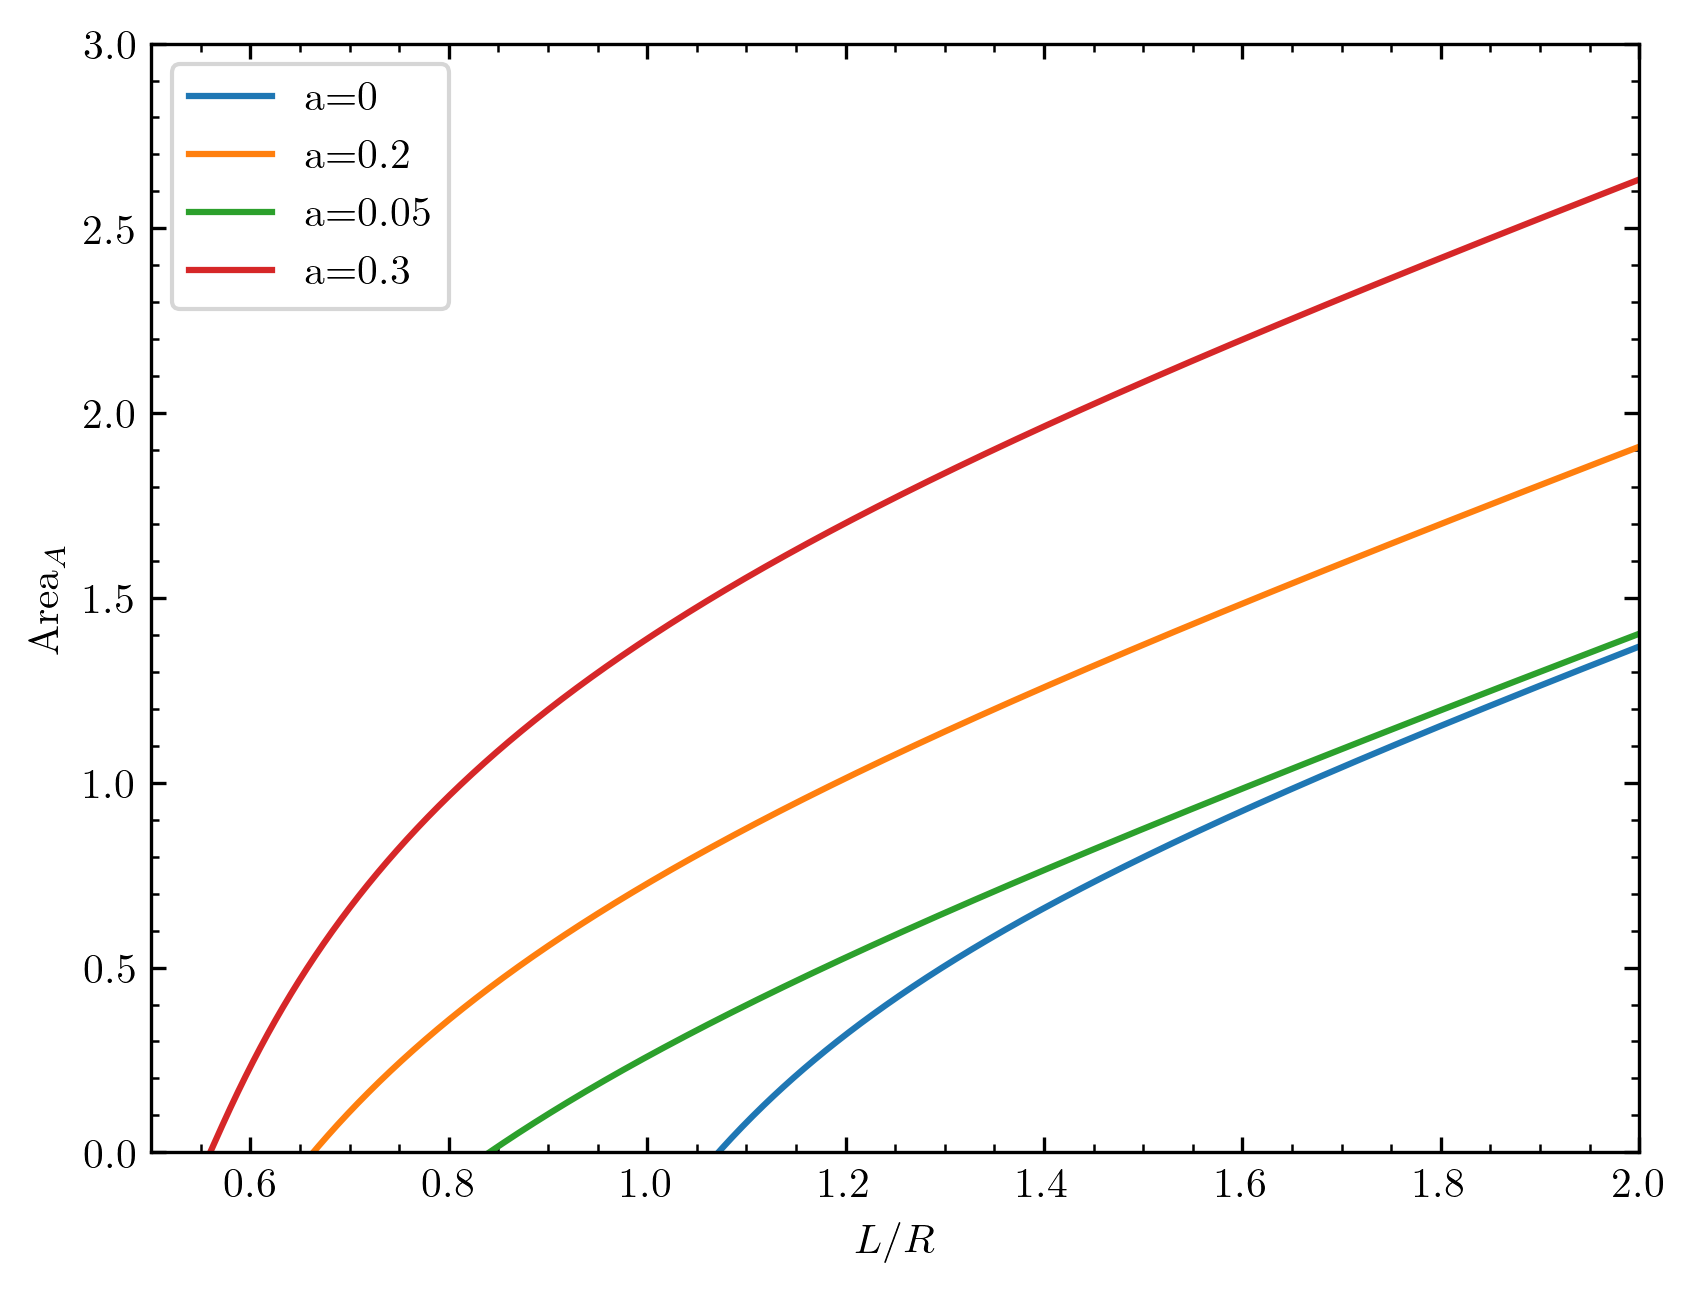

In [43]:
plt.plot(cLvsrminarr,cunArea,label='a=0')
plt.plot(adjncLvsrminarr,ncunArea,label='a=0.2')
plt.plot(adjncLvsrminarr2,ncunArea2,label='a=0.05')
plt.plot(adjncLvsrminarr3,ncunArea3,label='a=0.3')
plt.legend()
# plt.semilogy()
plt.xlabel(r'$ L / R$')
plt.ylabel(r'Area$_A$')
plt.ylim((0,3))
plt.xlim((0.5,2))
# plt.show()
plt.savefig('combFigs/unArea.pdf',format='pdf')

In [44]:
cLCArr = sf.LCritFunc(cLvsrminarr,calphagrid[cmask],cunArea,careaInt[cmask])
ncLCArr = sf.LCritFunc(adjncLvsrminarr,ncalphagrid[ncmask],ncunArea,ncareaInt[ncmask])
ncLCArr2 = sf.LCritFunc(adjncLvsrminarr2,ncalphagrid[ncmask],ncunArea2,ncareaInt[ncmask])
ncLCArr3 = sf.LCritFunc(adjncLvsrminarr3,ncalphagrid[ncmask],ncunArea3,ncareaInt[ncmask])

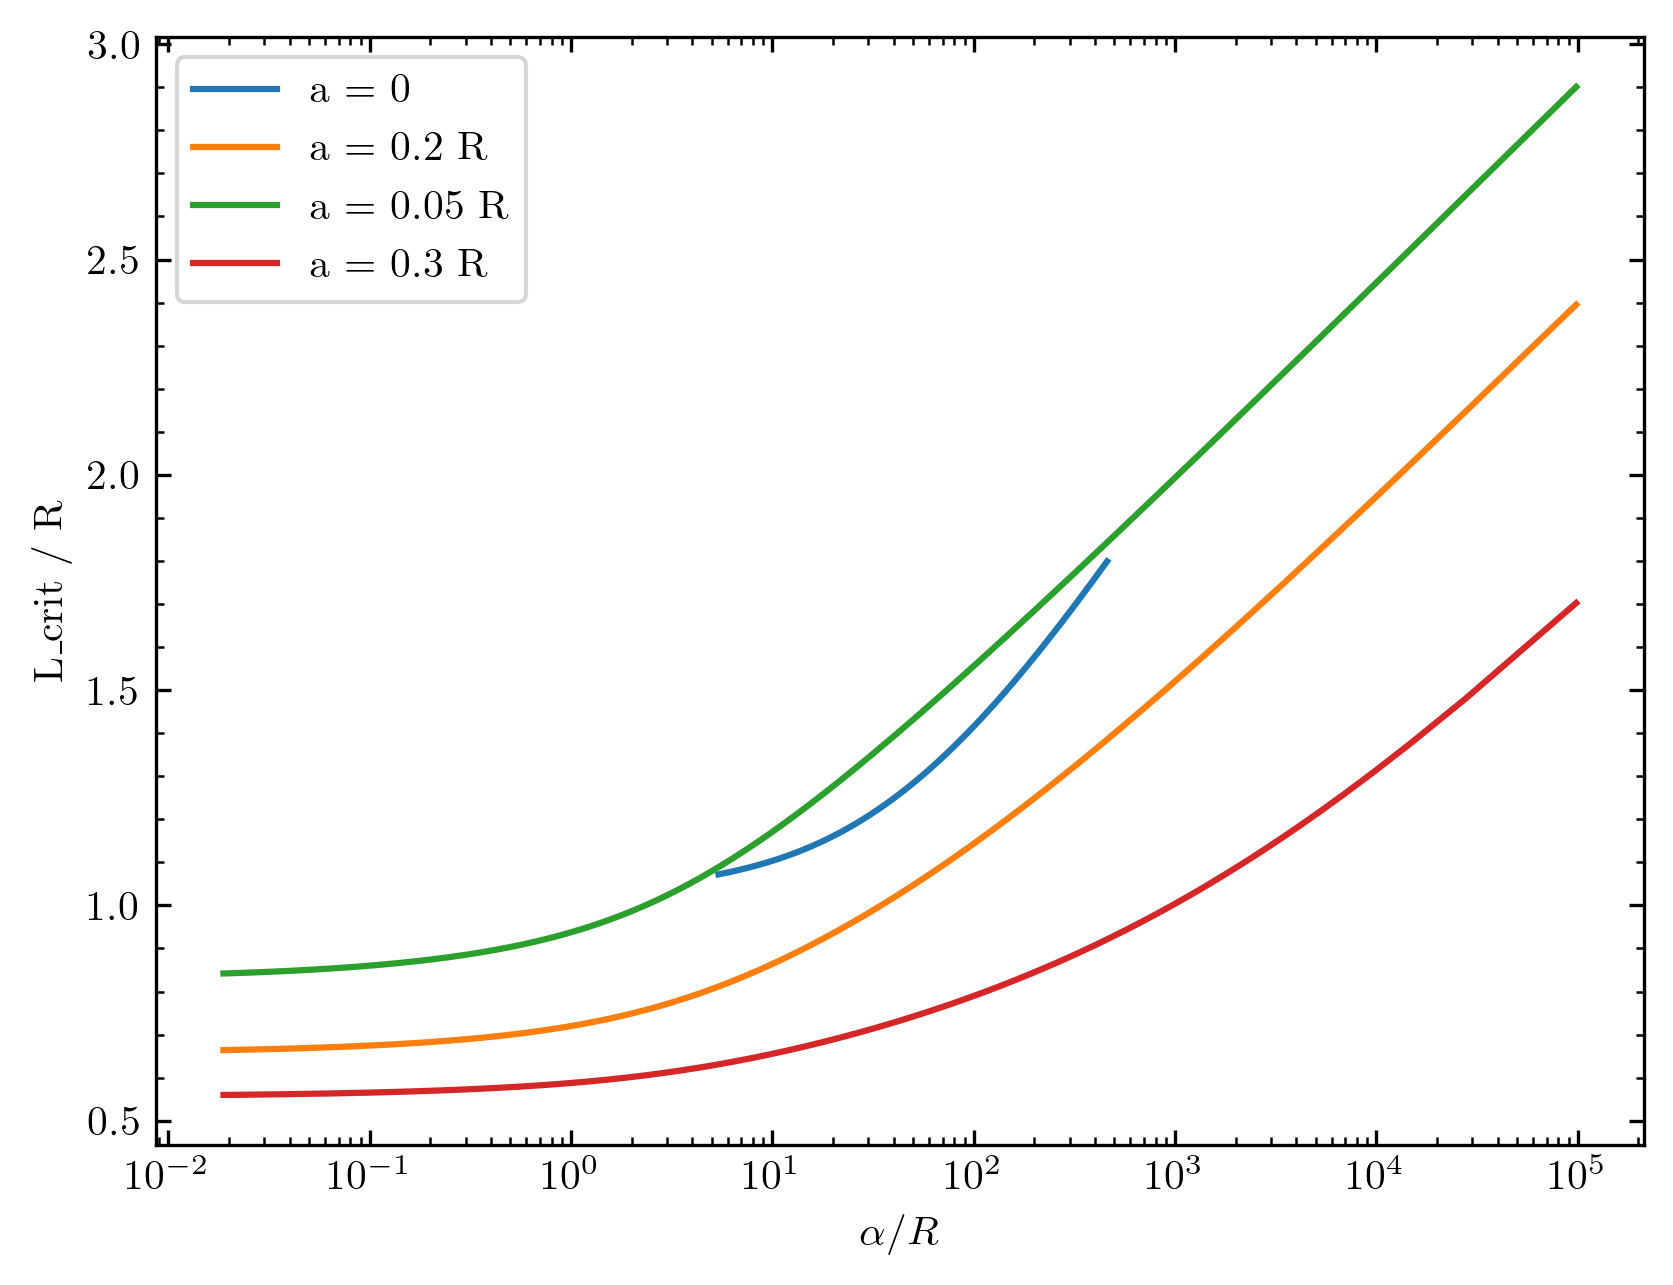

In [45]:
plt.plot(calphagrid[cmask],cLCArr,label='a = 0')
plt.plot(ncalphagrid[ncmask],ncLCArr,label='a = 0.2 R')
plt.plot(ncalphagrid[ncmask],ncLCArr2,label='a = 0.05 R')
plt.plot(ncalphagrid[ncmask],ncLCArr3,label='a = 0.3 R')
plt.semilogx()
plt.xlabel(r'$\alpha / R$')
plt.ylabel(r'L_{crit} / R')
plt.legend()
# plt.show()
plt.savefig('combFigs/Lcrit.pdf',format='pdf')